# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [ ]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42
)
df = pd.DataFrame(X, columns=["followers", "friends"])
df["label"] = y

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [ ]:
print(df.head())

   followers   friends  label
0  -0.872929  0.013042      1
1   1.312935  2.770534      1
2   2.340428  2.420996      1
3   2.294548 -0.404380      1
4   0.944105  0.477241      1


Display the summary of all the features of the dataset using `.info()`

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   followers  200 non-null    float64
 1   friends    200 non-null    float64
 2   label      200 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.8 KB
None


Display the total number of samples from each label using `.value_counts()`

In [ ]:
print(df["label"].value_counts())

label
1    100
0    100
Name: count, dtype: int64


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

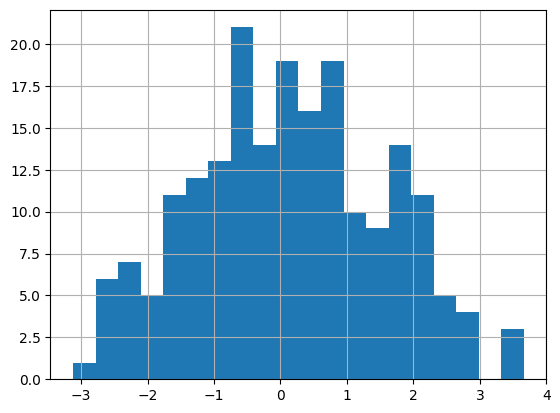

In [ ]:
df["followers"].hist(bins=20)
plt.show()

Remove the name column using `drop()` method

In [ ]:
# put your answer here

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [ ]:
X = df.drop("label", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [ ]:
y = df["label"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Display the dimensions of each variables using `.shape()`

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (140, 2)
X_test: (60, 2)
y_train: (140,)
y_test: (60,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [ ]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

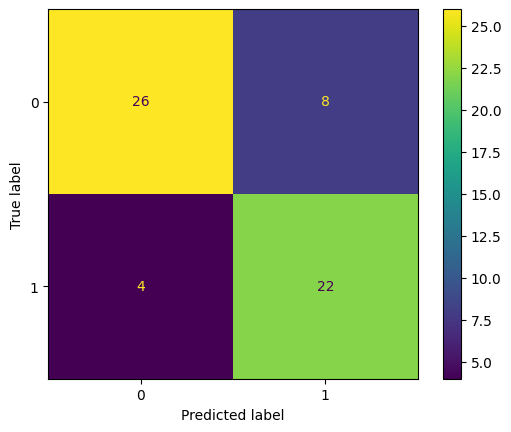

In [ ]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

Display the accuracy

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8


Display the precision

In [ ]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.7333333333333333


Display the recall

In [ ]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.8461538461538461


Display the f1-score

In [ ]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.7857142857142857


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [ ]:
my_features = [[200, 150]]
prediction = knn.predict(my_features)
print("Predicted personality:", "Extrovert" if prediction[0] == 1 else "Introvert")

Predicted personality: Extrovert
